# Naive Bayes

In [ ]:
# 👉 Ye ek classification algorithm hai
# 👉 Based on Bayes Theorem

# 👉 “Probability se decide karta hai ki data kis class me jayega”

# “Given data → kaunsi class sabse zyada probable hai?”
# 👉 Meaning:

# The model calculates probability for each class
# (e.g., Select and Not Select)

# 👉 Then it compares them:
# Which probability is higher

# 👉 The class with highest probability → final answer

# Example:
# P(Select) = 0.8
# P(Not Select) = 0.2

# 👉 Output = Select (because 0.8 > 0.2)
 
# ========================================================================

# Socho:
# 👉 Tum predict kar rahe ho:
# Candidate select hoga ya nahi

# Input:
# Experience = High
# Skills = Good

# Model kya karta hai?
# 👉 2 probability calculate karega:
# P(Select | data)
# P(Not Select | data)
# 👉 Jo bada → wahi answer

# ===============================================================================

# 🤯  “Naive” kyu?
# 👉 Ye assume karta hai:
# Sab features independent hain

# Example:
# Experience aur Skills → related ho sakte hain
# 👉 But model assume karta hai → unrelated

# =====================================================================================

# 👉 “Naive” matlab:
# Sab features independent maan leta hai ❗

# Example:
# Age, salary, city → ek dusre se related nahi (assume karta hai)

# Conditional Probability (Base concept)
# Formula:
# P(A|B) = P(B|A)P(A) / P(B)


# Types of Naive Bayes

In [ ]:
# 1. Gaussian Naive Bayes
# 👉 Use hota hai continuous (numeric) data ke liye

# Example:
# Age
# Salary
# Marks

# 👉 Assume karta hai:
# Data normal distribution (bell curve) follow karta hai

# ===========================================================================

# 2. Multinomial Naive Bayes
# 👉 Use hota hai text / count data ke liye

# Example:
# Email me word count
# “free” word kitni baar aaya

# 👉 NLP (text classification) me most use 🔥

# ==================================================================================

# 3. Bernoulli Naive Bayes
# 👉 Use hota hai binary data (0/1) ke liye

# Example:
# Word present (1) / absent (0)
# Yes / No


# | Type        | Data Type  | Example        |
# | ----------- | ---------- | -------------- |
# | Gaussian    | Continuous | salary, age    |
# | Multinomial | Count/Text | word frequency |
# | Bernoulli   | Binary     | 0/1, yes/no    |


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.plotting import plot_decision_regions

In [4]:
df = pd.read_csv(r"C:\Users\harsh\Downloads\archive\house_price_regression_dataset.csv")

In [5]:
df.head(3)

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,262382.852274
1,4272,3,3,2016,4.753014,1,6,985260.854490
2,3592,1,2,2016,3.634823,0,9,777977.390119


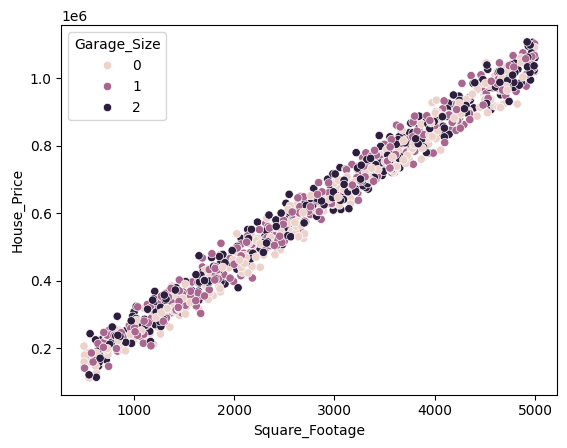

In [9]:
sns.scatterplot(x="Square_Footage", y="House_Price", data=df, hue="Garage_Size")
plt.show()

In [12]:
x = df.iloc[:, :-1]
# 👉 last column chhod kar baaki sab features

y = df["Garage_Size"]
# 👉 target column (Garage_Size)

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

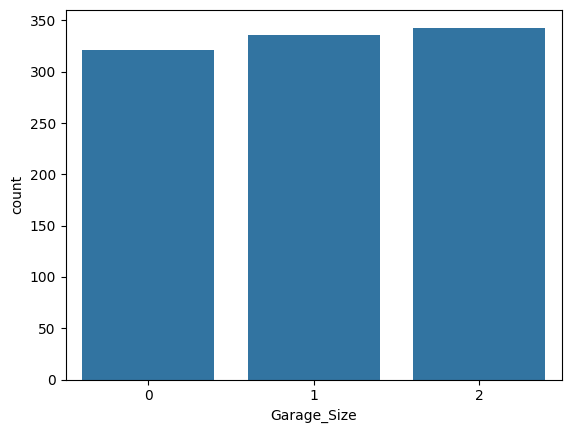

In [17]:
sns.countplot(x="Garage_Size", data=df)
plt.show()

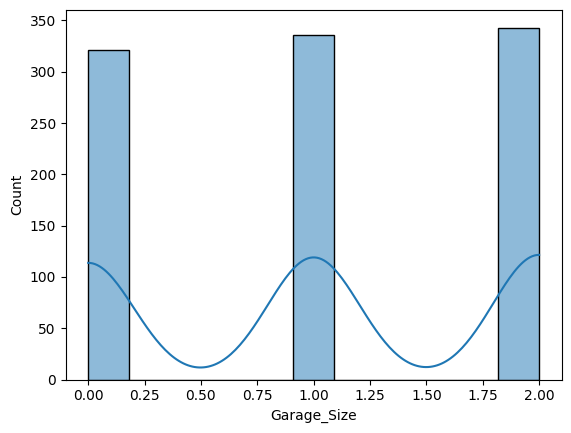

In [18]:
sns.histplot(df["Garage_Size"], kde=True)
plt.show()

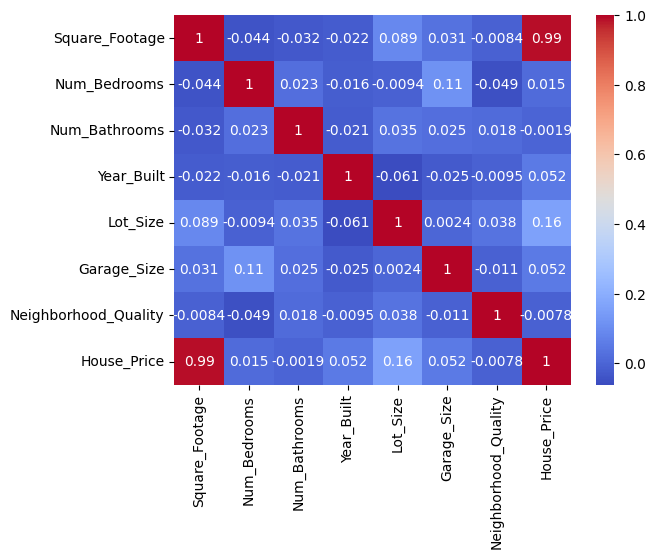

In [16]:
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

In [ ]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB

#  GaussianNB      # for continuous data
#  MultinomialNB   # for text/count data
#  BernoulliNB     # for binary (0/1) data

In [ ]:
# 👉 Create Gaussian Naive Bayes model
gnb = GaussianNB()

# 👉 Train (fit) the model on training data
gnb.fit(x_train, y_train)

# 👉 Model learns patterns from x_train and y_train

,priors,None
,var_smoothing,1e-09


In [25]:
gnb.score(x_test, y_test)*100, gnb.score(x_train, y_train)*100

(100.0, 100.0)

In [27]:
mnb = MultinomialNB()
mnb.fit(x_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [28]:
mnb.score(x_test, y_test)*100, mnb.score(x_train, y_train)*100

(33.0, 37.5)

In [29]:
bnb = BernoulliNB()
bnb.fit(x_train, y_train)

,alpha,1.0
,force_alpha,True
,binarize,0.0
,fit_prior,True
,class_prior,None


In [30]:
bnb.score(x_test, y_test)*100, bnb.score(x_train, y_train)*100

(63.0, 67.25)

c:\Users\harsh\Desktop\Saloni\ML\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but BernoulliNB was fitted with feature names
  warnings.warn(


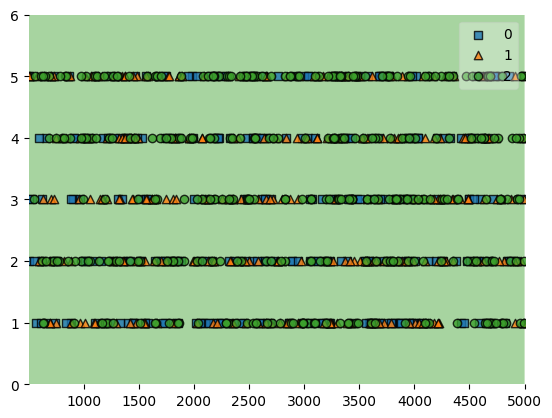

In [49]:
bnb.fit(x_2d, y)
plot_decision_regions(x_2d.to_numpy(), y.to_numpy(), clf=bnb)
plt.show()

c:\Users\harsh\Desktop\Saloni\ML\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MultinomialNB was fitted with feature names
  warnings.warn(


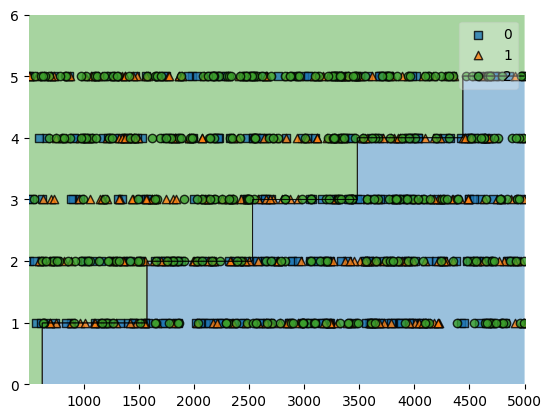

In [46]:
mnb.fit(x_2d, y)
plot_decision_regions(x_2d.to_numpy(), y.to_numpy(), clf=mnb)
plt.show()

c:\Users\harsh\Desktop\Saloni\ML\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


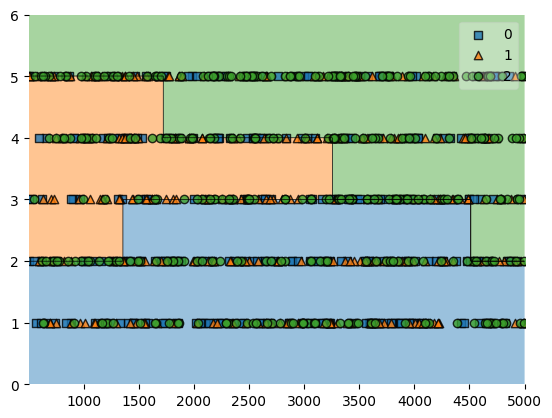

In [50]:
gnb.fit(x_2d, y)
plot_decision_regions(x_2d.to_numpy(), y.to_numpy(), clf=gnb)
plt.show()